In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
# Repository Clone
%cd /kaggle/working
!git clone https://github.com/LakshayBaijal/Computer-Vision_Assignments_Lakshay.git
%cd /kaggle/working/Computer-Vision_Assignments_Lakshay/Q1

/kaggle/working
Cloning into 'Computer-Vision_Assignments_Lakshay'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 30 (delta 1), reused 27 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 344.64 KiB | 10.14 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/kaggle/working/Computer-Vision_Assignments_Lakshay/Q1


In [5]:
from pathlib import Path

# Find Q1 repo folder in /kaggle/working
repo_candidates = list(Path("/kaggle/working").rglob("Q1/train.py"))
assert repo_candidates, "Q1/train.py not found. Clone repo first."
REPO = repo_candidates[0].parent
print("REPO:", REPO)

# Find dataset root in /kaggle/input (must contain img + annots)
data_root = None
for d in Path("/kaggle/input").rglob("*"):
    if d.is_dir() and (d / "img").exists() and (d / "annots").exists():
        data_root = d
        break

assert data_root is not None, "Dataset root with img/ and annots/ not found in /kaggle/input"
print("DATA_ROOT:", data_root)
print("Images:", len(list((data_root / "img").glob("*"))))
print("Annots:", len(list((data_root / "annots").glob("*.json"))))

REPO: /kaggle/working/Computer-Vision_Assignments_Lakshay/Q1
DATA_ROOT: /kaggle/input/datasets/lakshaybaijal/q1-dataset
Images: 904
Annots: 1254


In [6]:
%pip install -q einops matplotlib "numpy>=1.26,<2.2" opencv-python PyYAML tqdm shapely Pillow

Note: you may need to restart the kernel to use updated packages.


In [7]:
import yaml
from pathlib import Path

base_cfg = REPO / "config" / "st.yaml"
run_cfg = Path("/kaggle/working/run1_aabb_hp1.yaml")

with open(base_cfg, "r") as f:
    cfg = yaml.safe_load(f)

cfg["dataset_params"]["root_dir"] = str(data_root)
cfg["train_params"]["use_angle"] = False
cfg["train_params"]["num_epochs"] = 10
cfg["train_params"]["task_name"] = "/kaggle/working/Q1_run1_aabb_hp1_ckpts"
cfg["train_params"]["ckpt_name"] = "aabb_hp1.pth"

# optional (kept explicit)
cfg["train_params"]["lr"] = 1e-3
cfg["train_params"]["lr_steps"] = [7, 9]

with open(run_cfg, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print("Saved config:", run_cfg)
print(cfg["train_params"])

Saved config: /kaggle/working/run1_aabb_hp1.yaml
{'task_name': '/kaggle/working/Q1_run1_aabb_hp1_ckpts', 'seed': 1111, 'infer_seed': 1122, 'acc_steps': 1, 'num_epochs': 10, 'lr_steps': [7, 9], 'lr': 0.001, 'ckpt_name': 'aabb_hp1.pth', 'use_angle': False}


In [8]:
import os, sys
os.chdir(str(REPO))
sys.path.insert(0, str(REPO))

from train import train

class Args:
    config_path = "/kaggle/working/run1_aabb_hp1.yaml"
    root_dir = str(data_root)

train(Args())

Using device: cuda
{'dataset_params': {'root_dir': '/kaggle/input/datasets/lakshaybaijal/q1-dataset', 'num_classes': 2}, 'model_params': {'im_channels': 3, 'aspect_ratios': [0.5, 1, 2], 'scales': [128, 256, 512], 'min_im_size': 600, 'max_im_size': 1000, 'backbone_out_channels': 512, 'fc_inner_dim': 1024, 'rpn_bg_threshold': 0.3, 'rpn_fg_threshold': 0.7, 'rpn_nms_threshold': 0.7, 'rpn_train_prenms_topk': 12000, 'rpn_test_prenms_topk': 6000, 'rpn_train_topk': 2000, 'rpn_test_topk': 300, 'rpn_batch_size': 256, 'rpn_pos_fraction': 0.5, 'roi_iou_threshold': 0.5, 'roi_low_bg_iou': 0.0, 'roi_pool_size': 7, 'roi_nms_threshold': 0.3, 'roi_topk_detections': 100, 'roi_score_threshold': 0.05, 'roi_batch_size': 128, 'roi_pos_fraction': 0.25, 'bbox_reg_weights': [10.0, 10.0, 5.0, 5.0, 1.0]}, 'train_params': {'task_name': '/kaggle/working/Q1_run1_aabb_hp1_ckpts', 'seed': 1111, 'infer_seed': 1122, 'acc_steps': 1, 'num_epochs': 10, 'lr_steps': [7, 9], 'lr': 0.001, 'ckpt_name': 'aabb_hp1.pth', 'use_angl

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 213MB/s]  


Using angle prediction: False
Checkpoints will be saved to: /kaggle/working/Q1_run1_aabb_hp1_ckpts
Effective learning rate: 0.001


...

Finished epoch 7
Checkpoint saved: /kaggle/working/Q1_run1_aabb_hp1_ckpts/tv_frcnn_r50fpn_aabb_hp1.pth
RPN Classification Loss : 0.0180 | RPN Localization Loss : 0.0494 | FRCNN Classification Loss : 0.4757 | FRCNN Localization Loss : 0.2670


100%|██████████| 181/181 [02:57<00:00,  1.02it/s]


Finished epoch 8
Checkpoint saved: /kaggle/working/Q1_run1_aabb_hp1_ckpts/tv_frcnn_r50fpn_aabb_hp1.pth
RPN Classification Loss : 0.0162 | RPN Localization Loss : 0.0456 | FRCNN Classification Loss : 0.4494 | FRCNN Localization Loss : 0.2565


100%|██████████| 181/181 [02:58<00:00,  1.01it/s]


Finished epoch 9
Checkpoint saved: /kaggle/working/Q1_run1_aabb_hp1_ckpts/tv_frcnn_r50fpn_aabb_hp1.pth
RPN Classification Loss : 0.0130 | RPN Localization Loss : 0.0423 | FRCNN Classification Loss : 0.4223 | FRCNN Localization Loss : 0.2455
Done Training...


In [9]:
import glob, os, shutil, json
from IPython.display import FileLink, display, HTML

ckpt_dir = "/kaggle/working/Q1_run1_aabb_hp1_ckpts"
ckpts = sorted(glob.glob(os.path.join(ckpt_dir, "*.pth")))
assert ckpts, f"No .pth found in {ckpt_dir}"

print("Checkpoint count:", len(ckpts))
print("Latest:", ckpts[-1])

export_dir = "/kaggle/working/EXPORT_Q1_RUN1_AABB_HP1"
os.makedirs(export_dir, exist_ok=True)

# copy latest + manifest
shutil.copy2(ckpts[-1], os.path.join(export_dir, "Q1_RUN1_AABB_HP1_final.pth"))
with open(os.path.join(export_dir, "Q1_RUN1_AABB_HP1_manifest.json"), "w") as f:
    json.dump({"all_checkpoints": ckpts, "latest": ckpts[-1]}, f, indent=2)

zip_path = shutil.make_archive("/kaggle/working/Q1_RUN1_AABB_HP1_EXPORT", "zip", export_dir)
print("ZIP:", zip_path)

display(FileLink("/kaggle/working/Q1_RUN1_AABB_HP1_EXPORT.zip"))
display(HTML('<script>window.open("/files/Q1_RUN1_AABB_HP1_EXPORT.zip","_blank");</script>'))
print("If auto-download is blocked, click the link above.")

Checkpoint count: 1
Latest: /kaggle/working/Q1_run1_aabb_hp1_ckpts/tv_frcnn_r50fpn_aabb_hp1.pth
ZIP: /kaggle/working/Q1_RUN1_AABB_HP1_EXPORT.zip


/kaggle/working/Q1_RUN1_AABB_HP1_EXPORT.zip

If auto-download is blocked, click the link above.


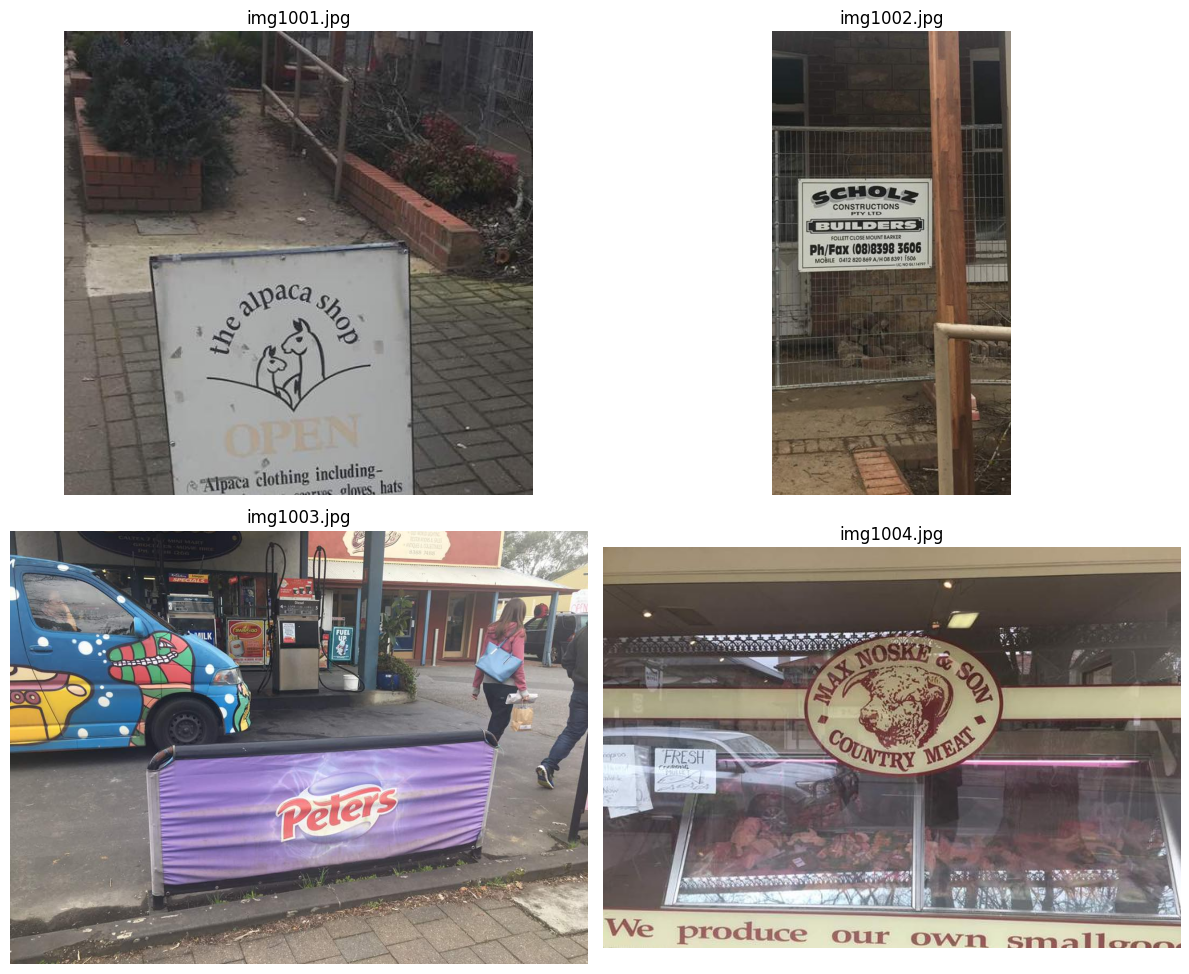

In [10]:
import cv2, json
import matplotlib.pyplot as plt
from pathlib import Path

img_dir = data_root / "img"
ann_dir = data_root / "annots"

samples = sorted(img_dir.glob("*.jpg"))[:4]
fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.flatten()

for ax, img_path in zip(axes, samples):
    ann_path = ann_dir / f"{img_path.name}.json"
    im = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

    with open(ann_path, "r") as f:
        ann = json.load(f)

    for obj in ann:
        if "bbox" in obj:
            x1,y1,x2,y2 = map(int, obj["bbox"][:4])
            cv2.rectangle(im, (x1,y1), (x2,y2), (0,255,0), 2)

    ax.imshow(im)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()